# Insurance Cost — Exploratory Data Analysis

**Goal:** understand the drivers of individual medical `charges` before modeling.

Dataset: Kaggle *Medical Cost Personal* — 7 columns, ~1,338 rows.
Features: `age`, `sex`, `bmi`, `children`, `smoker`, `region`; target: `charges`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make the src package importable and reuse project config.
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src import config  # noqa: E402

sns.set_theme(style='whitegrid')
FIG = config.FIGURES_DIR
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(config.DATA_FILE)
df.shape

(1338, 7)

In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Structure, types, and data quality

In [3]:
df.info()
print('\nMissing values per column:')
print(df.isna().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


**Takeaways:** no missing values; one exact duplicate row (dropped during modeling). `charges` is strongly right-skewed, which we confirm next.

## 2. Target distribution (raw vs. log)

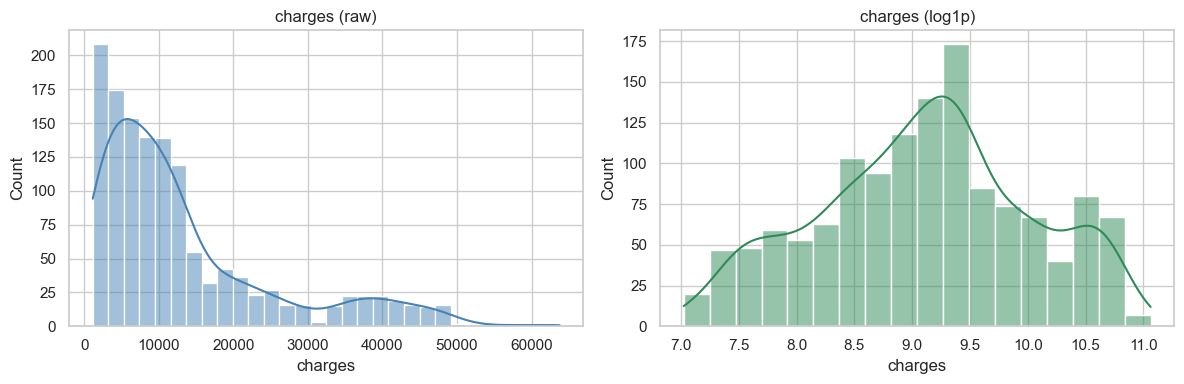

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('charges (raw)')
sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('charges (log1p)')
fig.tight_layout()
fig.savefig(FIG / 'eda_target_distribution.png', dpi=120)
plt.show()

The raw target is heavily right-skewed; a log transform makes it far more symmetric — useful for linear models (tree/boosting models are scale-invariant to the target).

## 3. The dominant driver: smoking

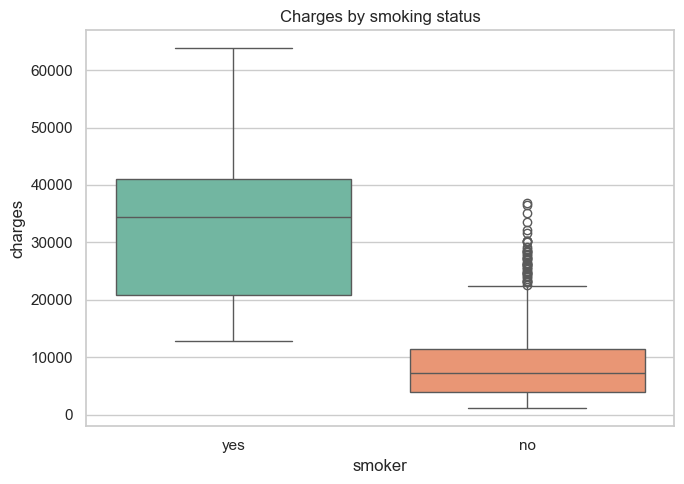

,mean,median,count
smoker,,,
no,8434.268298,7345.40530,1064
yes,32050.231832,34456.34845,274


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', palette='Set2', ax=ax, legend=False)
ax.set_title('Charges by smoking status')
fig.tight_layout()
fig.savefig(FIG / 'eda_charges_by_smoker.png', dpi=120)
plt.show()

df.groupby('smoker')['charges'].agg(['mean', 'median', 'count'])

Smokers pay several times more on average — this is by far the strongest single predictor.

## 4. Age and BMI, colored by smoking

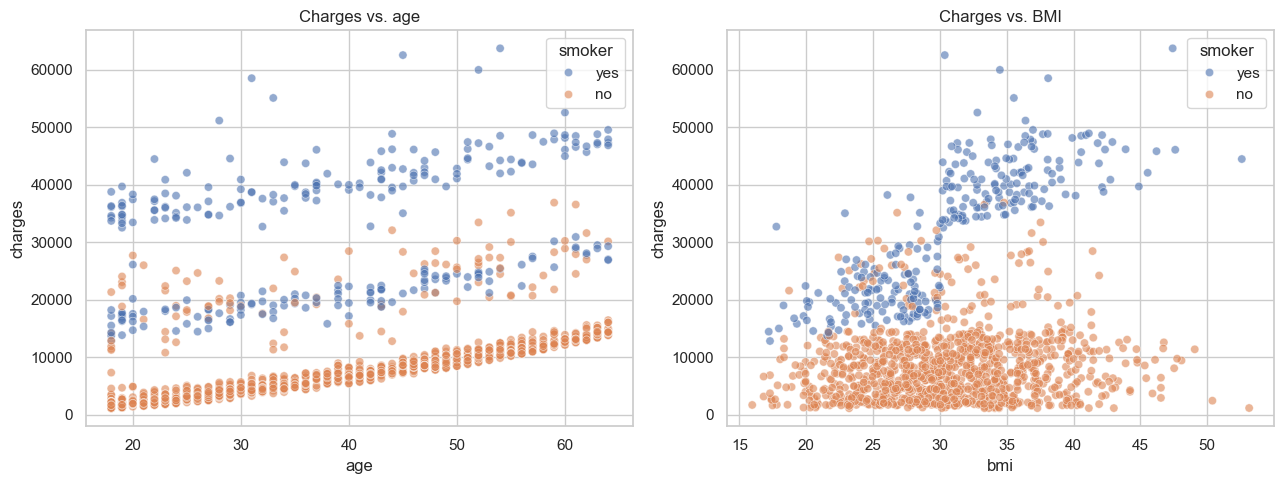

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=axes[0])
axes[0].set_title('Charges vs. age')
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[1])
axes[1].set_title('Charges vs. BMI')
fig.tight_layout()
fig.savefig(FIG / 'eda_age_bmi_scatter.png', dpi=120)
plt.show()

Charges rise with age in roughly parallel bands. For BMI, the effect is concentrated in **smokers**: above BMI ~30 (obese) smoker charges jump sharply — an interaction effect.

## 5. BMI ≥ 30 × smoker interaction

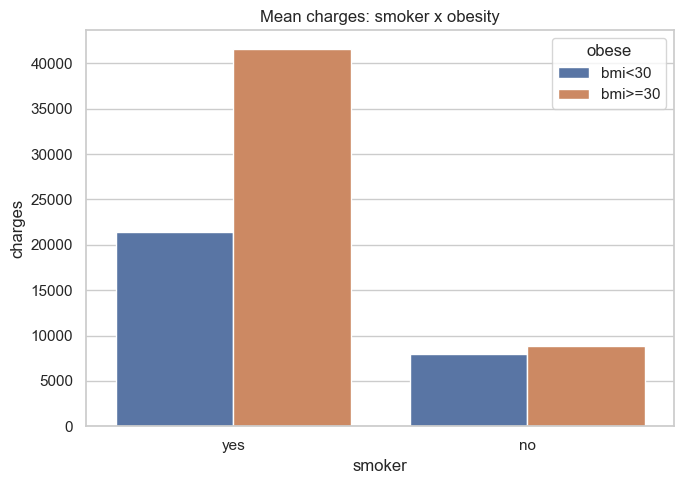

obese,bmi<30,bmi>=30
smoker,,
no,7977.029520,8842.691548
yes,21363.217016,41557.989840


In [8]:
tmp = df.assign(obese=np.where(df['bmi'] >= 30, 'bmi>=30', 'bmi<30'))
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=tmp, x='smoker', y='charges', hue='obese', errorbar=None, ax=ax)
ax.set_title('Mean charges: smoker x obesity')
fig.tight_layout()
fig.savefig(FIG / 'eda_smoker_bmi_interaction.png', dpi=120)
plt.show()

tmp.groupby(['smoker', 'obese'])['charges'].mean().unstack()

## 6. Region, sex, and children

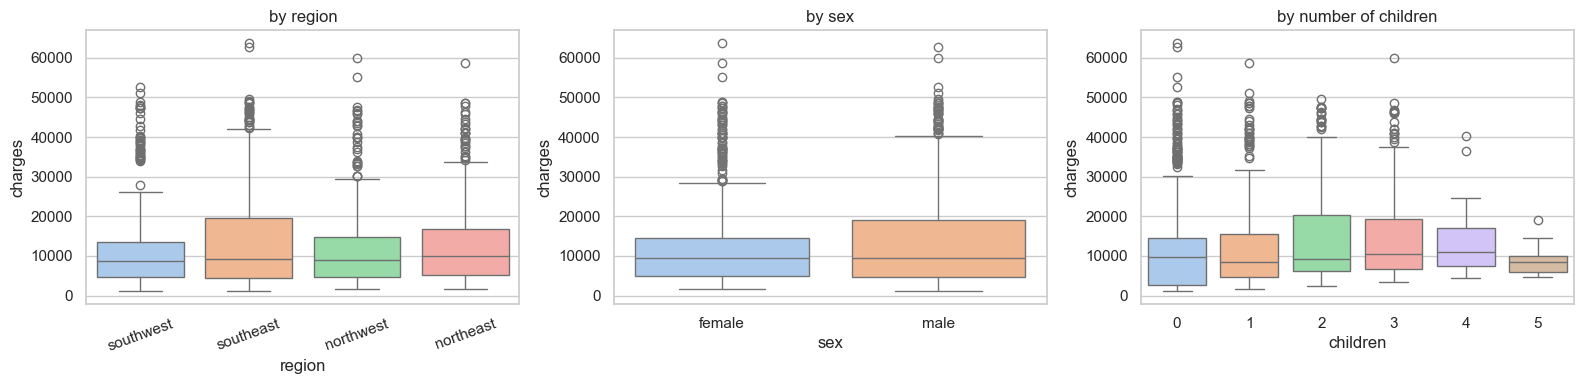

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x='region', y='charges', hue='region', palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('by region'); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='sex', y='charges', hue='sex', palette='pastel', ax=axes[1], legend=False)
axes[1].set_title('by sex')
sns.boxplot(data=df, x='children', y='charges', hue='children', palette='pastel', ax=axes[2], legend=False)
axes[2].set_title('by number of children')
fig.tight_layout()
fig.savefig(FIG / 'eda_region_sex_children.png', dpi=120)
plt.show()

Region and sex show only mild differences; number of children has a weak effect. None rival smoking, age, or BMI.

## 7. Correlations (numeric + encoded smoker)

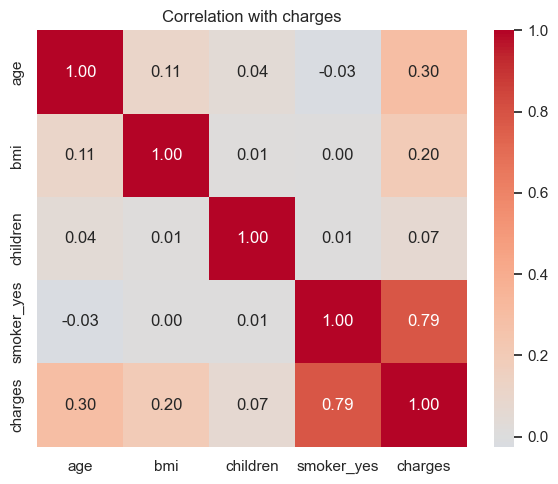

In [10]:
num = df.copy()
num['smoker_yes'] = (num['smoker'] == 'yes').astype(int)
corr = num[['age', 'bmi', 'children', 'smoker_yes', 'charges']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation with charges')
fig.tight_layout()
fig.savefig(FIG / 'eda_correlation.png', dpi=120)
plt.show()

## Summary

- **Smoking** is the dominant cost driver; **age** and **BMI** follow.
- A clear **smoker × BMI≥30** interaction — boosting models capture this automatically.
- `region`, `sex`, `children` are weak predictors.
- `charges` is right-skewed; helpful to log-transform for linear models.

Next: `python -m src.train` fits and compares models and saves the best pipeline.